# Vortex sheddding analysis

In [1]:
import sys
import os

src_path = os.path.split(os.getcwd())[0]
sys.path.insert(0, src_path)

### Aspect ratio

In [2]:
from src import utils
from tqdm import tqdm
import numpy as np

ratio = [i*0.25 for i in range(2, 13)]
path = r"..\data\aspect_ratio\reynolds_100\laminar_ratio"
data_paths = [f'{path}_{str(i).replace(".","_")}.csv' for i in ratio]

fft_list = []
lomb_list = []
fft_strou = []
lomb_strou = []
for data_path in tqdm(data_paths):
    data = utils.get_time_series(data_path, "p5", "uy")
    fft_freq = utils.get_frequency_fourier(*data)
    lomb_freq = utils.get_frequency_lombscargle(*data, freqs=np.linspace(0.001,5, 20000))

    fft_list.append(fft_freq)
    lomb_list.append(lomb_freq)
    fft_strou.append(utils.strouhal_number(fft_freq, 0.03, 0.05))
    lomb_strou.append(utils.strouhal_number(lomb_freq, 0.03, 0.05))


100%|██████████| 11/11 [01:03<00:00,  5.76s/it]


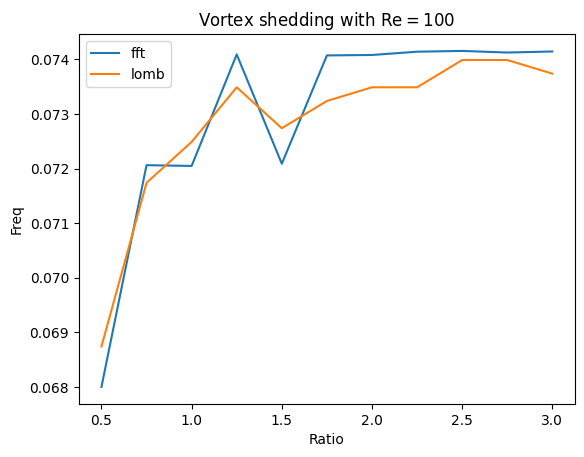

In [3]:
import matplotlib.pyplot as plt

plt.plot(ratio, fft_list, label = "fft")
plt.plot(ratio, lomb_list, label = "lomb")
plt.title(r"Vortex shedding with $\text{Re}=100$")
plt.xlabel("Ratio")
plt.ylabel("Freq")
plt.legend()
plt.show()

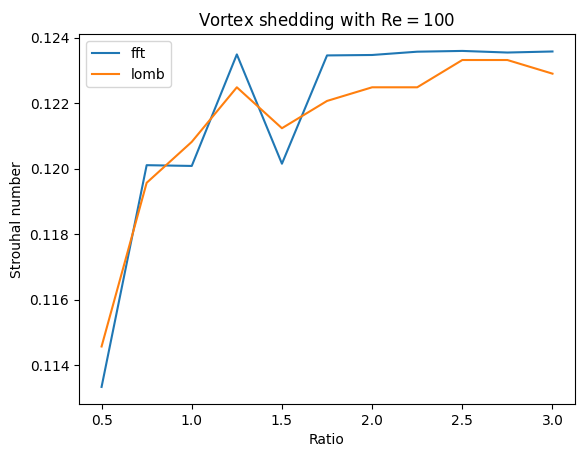

In [4]:
import matplotlib.pyplot as plt

plt.plot(ratio, fft_strou, label = "fft")
plt.plot(ratio, lomb_strou, label = "lomb")
plt.xlabel("Ratio")
plt.ylabel("Strouhal number")
plt.title(r"Vortex shedding with $\text{Re}=100$")
plt.legend()
plt.show()

### Velocity

In [5]:
from src import utils
from tqdm import tqdm
import numpy as np

rn1 = [20,50,100,500]
rn2 = [500, 1000, 5000, 10000, 50000, 100000, 500000,1000000]
path1 = r"..\data\velocity\laminar_reynolds"
path2 = r"..\data\velocity\les_reynolds"
data_paths = [f'{path1}_{i}.csv' for i in rn1] + [f'{path2}_{i}.csv' for i in rn2]

fft_list = []
lomb_list = []
fft_strou = []
lomb_strou = []
for i, data_path in tqdm(enumerate(data_paths), total=len(data_paths)):
    data = utils.get_time_series(data_path, "p3", "uy")
    fft_freq = utils.get_frequency_fourier(*data)
    lomb_freq = utils.get_frequency_lombscargle(*data, freqs=np.linspace(0.001,(rn1+rn2)[i]/100, 20000))

    fft_list.append(fft_freq)
    lomb_list.append(lomb_freq)
    if (fft_freq != np.nan):
        fft_strou.append(utils.strouhal_number(fft_freq, utils.reynolds_to_velocity[(rn1+rn2)[i]], 0.05))
    else:
        fft_strou.append(np.nan)
    if lomb_strou != np.nan:
        lomb_strou.append(utils.strouhal_number(lomb_freq, utils.reynolds_to_velocity[(rn1+rn2)[i]], 0.05))
    else:
        lomb_strou.append(np.nan)

100%|██████████| 12/12 [01:05<00:00,  5.50s/it]


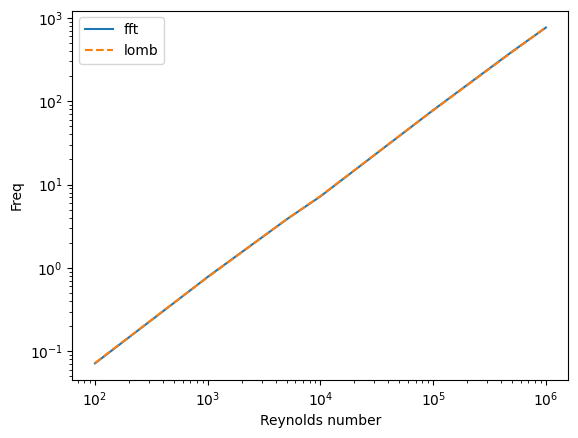

In [6]:
import matplotlib.pyplot as plt

fig = plt.figure()
plt.plot(rn1+rn2, fft_list, label = "fft")
plt.plot(rn1+rn2, lomb_list, label = "lomb", linestyle="--")
plt.xlabel("Reynolds number")
plt.ylabel("Freq")
plt.xscale("log")
plt.title("")
plt.yscale("log")
plt.legend()
plt.show()

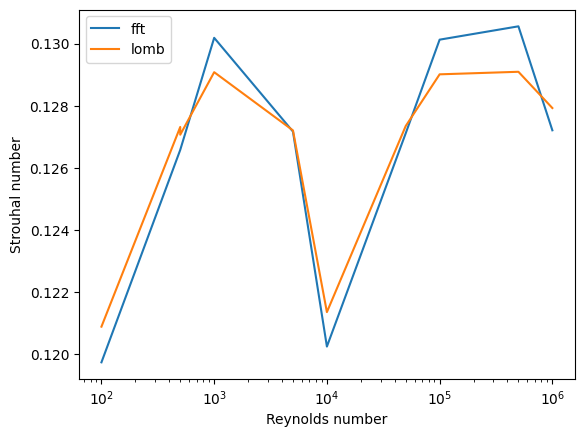

In [7]:
fig = plt.figure()
plt.plot(rn1+rn2, fft_strou, label = "fft")
plt.plot(rn1+rn2, lomb_strou, label = "lomb")
plt.xlabel("Reynolds number")
plt.ylabel("Strouhal number")
plt.xscale("log")
plt.legend()
plt.show()